In [1]:
import brightway2 as bw
from brightway2 import *
import os
import wurst
import time
import openpyxl
import copy
import numpy as np
import pandas as pd
import glob as glob
import matplotlib.pyplot as plt

In [2]:
startTime = time.time() # just to see how much time the code takes to run (this is the start)

In [3]:
bw.projects.set_current('Prospective LCA v5') # set current project

In [4]:
newLocations = {'BR' : 'Brazil',
                'CA' : 'Canada',
                'PL' : 'Central Europe',
                'CN' : 'China',
                'ET' : 'Eastern Africa',
                'IN' : 'India',
                'ID' : 'Indonesia',
                'JP' : 'Japan',
                'KR' : 'Korea',
                'IR' : 'Middle East',
                'MX' : 'Mexico',
                'EG' : 'Northern Africa',
                'AU' : 'Oceania',
                'GT' : 'Rest of Central America',
                'BW' : 'Rest of Southern Africa',
                'CL' : 'Rest of Southern America',
                'PK' : 'Rest of Southern Asia',
                'RU' : 'Russia',
                'ZA' : 'South Africa',
                'PH' : 'South Eastern Asia',
                'UZ' : 'Central Asia',
                'TR' : 'Turkey',
                'UA' : 'Ukraine',
                'US' : 'United States of America',
                'NG' : 'Western Africa',
                'RER' : 'Western Europe'}

In [5]:
allDBNames = list(bw.databases)

In [6]:
ecoinventSSP2DBNames = ['SSP2-Base 2020',
                        'SSP2-Base 2050',
                        'SSP2-RCP19 2050']

In [7]:
regionGroups = {
    'BRA' : ['Brazil'],
    'CAN' : ['Canada'],
    'CEU' : ['Albania', 'Bosnia and Herzegovina', 'Bulgaria', 'Cyprus', 'Czechia', 'Estonia', 'Croatia', 'Hungary', 'Lithuania',
             'Latvia', 'North Macedonia', 'Poland', 'Romania', 'Republic of Serbia', 'Slovenia', 'Slovakia', 'Kosovo', 'Northern Cyprus'],
    'CHN' : ['China', 'Mongolia', 'Taiwan'],
    'EAF' : ['Eritrea', 'Ethiopia', 'Kenya', 'Madagascar', 'Mauritius', 'Rwanda', 'Sudan', 'South Sudan', 'Somalia', 'Burundi', 'Djibouti',
             'Somaliland'],
    'INDIA' : ['India'],
    'INDO' : ['Indonesia', 'Papua New Guinea'],
    'JAP' : ['Japan'],
    'KOR' : ['North Korea', 'South Korea'],
    'ME' : ['United Arab Emirates', 'Bahrain', 'Israel', 'Iraq', 'Iran', 'Jordan', 'Kuwait', 'Lebanon', 'Montenegro', 'Saudi Arabia',
            'Oman', 'Yemen', 'Syria', 'Qatar', 'Palestine'],
    'MEX' : ['Mexico'],
    'NAF' : ['Algeria', 'Egypt', 'Libya', 'Morocco', 'Tunisia', 'Western Sahara'],
    'OCE' : ['Australia', 'New Zealand', 'Fiji', 'Vanuatu', 'New Caledonia', 'Solomon Islands'],
    'RCAM' : ['Costa Rica', 'Cuba', 'Curaçao', 'Dominican Republic', 'Guatemala', 'Honduras', 'Haiti', 'Jamaica', 'Nicaragua',
             'El Salvador', 'Trinidad and Tobago', 'The Bahamas', 'Puerto Rico', 'Panama', 'Belize'],
    'RSAF' : ['Angola', 'Botswana', 'Mozambique', 'Namibia', 'United Republic of Tanzania', 'Zambia', 'Zimbabwe', 'Malawi', 'eSwatini', 'Lesotho', 'Uganda'],
    'RSAM' : ['Argentina', 'Falkland Is.', 'Bolivia', 'Chile', 'Colombia', 'Ecuador', 'Peru', 'Paraguay', 'Uruguay', 'Venezuela',
             'Guyana', 'Suriname'],
    'RSAS' : ['Bangladesh', 'Sri Lanka', 'Nepal', 'Pakistan', 'Bhutan', 'Afghanistan'],
    'RUS' : ['Armenia', 'Azerbaijan', 'Georgia', 'Russia'],
    'SAF' : ['South Africa'],
    'SEAS' : ['Brunei', 'Cambodia', 'Myanmar', 'Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Vietnam', 'Laos'],
    'STAN' : ['Kyrgyzstan', 'Kazakhstan', 'Tajikistan', 'Turkmenistan', 'Uzbekistan'],
    'TUR' : ['Turkey'],
    'UKR' : ['Belarus', 'Moldova', 'Ukraine'],
    'USA' : ['United States of America'],
    'WAF' : ['Benin', 'Democratic Republic of the Congo', 'Republic of the Congo', 'Ivory Coast', 'Cameroon', 'Gabon', 'Gambia', 'Ghana', 'Niger', 'Nigeria',
             'Senegal', 'Togo', 'Mauritania', 'Mali', 'Burkina Faso', 'Chad', 'Central African Republic', 'Guinea-Bissau', 'Guinea',
             'Sierra Leone', 'Liberia', 'Equatorial Guinea'],
    'WEU' : ['Austria', 'Belgium', 'Switzerland', 'Germany', 'Denmark', 'Spain', 'Finland', 'France', 'United Kingdom', 'Gibraltar',
             'Greece', 'Ireland', 'Iceland', 'Italy', 'Luxembourg', 'Malta', 'Netherlands', 'Norway', 'Portugal', 'Sweden'],
}

In [8]:
imageLocations = {'Global' : 'World',
                'Brazil' : 'BRA',
                'Canada' : 'CAN',
                'Central Europe' : 'CEU',
                'China' : 'CHN',
                'Eastern Africa' : 'EAF',
                'India' : 'INDIA',
                'Indonesia' : 'INDO',
                'Japan' : 'JAP',
                'Korea' : 'KOR',
                'Middle East' : 'ME',
                'Mexico' : 'MEX',
                'Northern Africa' : 'NAF',
                'Oceania' : 'OCE',
                'Rest of Central America' : 'RCAM',
                'Rest of Southern Africa' : 'RSAF',
                'Rest of Southern America' : 'RSAM',
                'Rest of Southern Asia' : 'RSAS',
                'Russia' : 'RUS',
                'South Africa' : 'SAF',
                'South Eastern Asia' : 'SEAS',
                'Central Asia' : 'STAN',
                'Turkey' : 'TUR',
                'Ukraine' : 'UKR',
                'United States of America' : 'USA',
                'Western Africa' : 'WAF',
                'Western Europe' : 'WEU'}

solarLocations = {'Brazil' : 'RoW',
                  'Canada' : 'CA-AB',
                  'Central Europe' : 'RoW',
                  'China' : 'CN-BJ',
                  'Eastern Africa' : 'RoW',
                  'India' : 'RoW',
                  'Indonesia' : 'RoW',
                  'Japan' : 'JP',
                  'Korea' : 'KR',
                  'Middle East' : 'RoW',
                  'Mexico' : 'MX',
                  'Northern Africa' : 'RoW',
                  'Oceania' : 'AU',
                  'Rest of Central America' : 'RoW',
                  'Rest of Southern Africa' : 'RoW',
                  'Rest of Southern America' : 'AR',
                  'Rest of Southern Asia' : 'RoW',
                  'Russia' : 'RoW',
                  'South Africa' : 'RoW',
                  'South Eastern Asia' : 'RoW',
                  'Central Asia' : 'RoW',
                  'Turkey' : 'RoW',
                  'Ukraine' : 'RoW',
                  'United States of America' : 'US-HICC',
                  'Western Africa' : 'RoW',
                  'Western Europe' : 'DE'}

windLocations =  {'Brazil' : 'RoW',
                  'Canada' : 'CA-AB',
                  'Central Europe' : 'BG',
                  'China' : 'CN-AH',
                  'Eastern Africa' : 'RoW',
                  'India' : 'IN-TN',
                  'Indonesia' : 'RoW',
                  'Japan' : 'JP',
                  'Korea' : 'KR',
                  'Middle East' : 'IR',
                  'Mexico' : 'MX',
                  'Northern Africa' : 'RoW',
                  'Oceania' : 'AU',
                  'Rest of Central America' : 'RoW',
                  'Rest of Southern Africa' : 'RoW',
                  'Rest of Southern America' : 'CL',
                  'Rest of Southern Asia' : 'RoW',
                  'Russia' : 'RU',
                  'South Africa' : 'ZA',
                  'South Eastern Asia' : 'RoW',
                  'Central Asia' : 'RoW',
                  'Turkey' : 'TR',
                  'Ukraine' : 'UA',
                  'United States of America' : 'US-ASCC',
                  'Western Africa' : 'RoW',
                  'Western Europe' : 'DE'}

In [9]:
"""for ecoinventSSP2DBName in ecoinventSSP2DBNames:
    
    ecoinventSSP2DB = bw.Database('ecoinvent 3.8 cutoff image ' + ecoinventSSP2DBName)
    # mySSP2DBName = ecoinventSSP2DBName.replace('ecoinvent 3.8 cutoff', 'lci-Abhi')
    mySSP2DB = bw.Database('lci-Abhi characterisation factors')
    # print('Started ' + mySSP2DBName)

    locations = imageLocations

    for value, location in locations.items():

        ecoinventLocation = find_key_by_value(newLocations, value)
        windLocation = find_value_by_key(windLocations, value)
        solarLocation = find_value_by_key(solarLocations, value)

        if ecoinventLocation:
            newLoc = ecoinventLocation
            
            solarElecAct = [activity for activity in ecoinventSSP2DB
                        if 'electricity production, photovoltaic, 570kWp open ground installation, multi-Si' in activity['name']
                        and 'electricity, low voltage' in activity['reference product']
                        and solarLocation == activity['location']]
            
            onshoreWindElecAct = [activity for activity in ecoinventSSP2DB
                        if 'electricity production, wind, >3MW turbine, onshore' in activity['name']
                        and 'electricity, high voltage' in activity['reference product']
                        and windLocation == activity['location']]
                
        else:
            newLoc = 'GLO'

            solarElecAct = [activity for activity in ecoinventSSP2DB
                        if 'electricity production, photovoltaic, 570kWp open ground installation, multi-Si' in activity['name']
                        and 'electricity, low voltage' in activity['reference product']
                        and 'RoW' in activity['location']]
            
            onshoreWindElecAct = [activity for activity in ecoinventSSP2DB
                        if 'electricity production, wind, >3MW turbine, onshore' in activity['name']
                        and 'electricity, high voltage' in activity['reference product']
                        and 'RoW' in activity['location']]

        solarElectActCopy = solarElecAct[0].copy(database = mySSP2DB.name, location = newLoc, name = 'solar ' + ecoinventSSP2DBName)
        onshoreWindElecActCopy = onshoreWindElecAct[0].copy(database = mySSP2DB.name, location = newLoc, name = 'onshore wind ' + ecoinventSSP2DBName)
        
    # print('Finished ', mySSP2DBName)"""

"for ecoinventSSP2DBName in ecoinventSSP2DBNames:\n    \n    ecoinventSSP2DB = bw.Database('ecoinvent 3.8 cutoff image ' + ecoinventSSP2DBName)\n    # mySSP2DBName = ecoinventSSP2DBName.replace('ecoinvent 3.8 cutoff', 'lci-Abhi')\n    mySSP2DB = bw.Database('lci-Abhi characterisation factors')\n    # print('Started ' + mySSP2DBName)\n\n    locations = imageLocations\n\n    for value, location in locations.items():\n\n        ecoinventLocation = find_key_by_value(newLocations, value)\n        windLocation = find_value_by_key(windLocations, value)\n        solarLocation = find_value_by_key(solarLocations, value)\n\n        if ecoinventLocation:\n            newLoc = ecoinventLocation\n            \n            solarElecAct = [activity for activity in ecoinventSSP2DB\n                        if 'electricity production, photovoltaic, 570kWp open ground installation, multi-Si' in activity['name']\n                        and 'electricity, low voltage' in activity['reference product']\n     

In [10]:
databaseNames = bw.databases
myDatabaseNames = []
for databaseName in databaseNames:
    if 'Abhi' in databaseName and 'image' not in databaseName:
        myDatabaseNames.append(databaseName)

In [11]:
myDatabaseNames

['lci-Abhi characterisation factors']

In [12]:
methodsDict = {'climate change' : ('IPCC 2013', 'climate change', 'GWP 20a, incl. H and bio CO2')}    

In [13]:
methodsList = []
solarResultsFileNames = []
onshoreWindResultsFileNames = []
for keys, values in methodsDict.items():  
    methodsList.append(values)
    solarResultsFileNames.append('solar ' + keys + ' results.xlsx')
    onshoreWindResultsFileNames.append('onshore wind ' + keys + ' results.xlsx')

allResultsFileNames = solarResultsFileNames + onshoreWindResultsFileNames

In [14]:
def lca_calculations(activities, methodsList):
    results = np.zeros((len(activities), len(methodsList)))
    lca = LCA({activities[0] : 1}, method = methodsList[0]) # LCA object which will do all calculating
    lca.lci() # calculate inventory once to load all database data
    lca.decompose_technosphere() # keep the LU factorized matrices for faster calculations
    lca.lcia() # load method data
    characterizationMatrices = []
    
    for method in methodsList:
        lca.switch_method(method)
        characterizationMatrices.append(lca.characterization_matrix.copy())
        
    for first, activity in enumerate(activities):
        lca.redo_lci({activity : 1})
        
        for second, matrix in enumerate(characterizationMatrices):
            results[first, second] = (matrix * lca.inventory).sum()
            
    return results

In [15]:
def check_or_create_excel_file(filePath):
    if not os.path.exists(filePath):
        wb = openpyxl.Workbook()
        wb.save(filePath)
        print(f'Excel file created at {filePath}')

In [16]:
def delete_first_sheet_from_excel_files(filePath):
    wb = openpyxl.load_workbook(filePath)
    if wb.sheetnames[0] == 'Sheet':  # check if the workbook has any sheets
        firstSheet = wb.sheetnames[0]  # get the name of the first sheet
        wb.remove(wb[firstSheet])  # remove the first sheet
        wb.save(filePath)

In [17]:
"""for myDatabaseName in myDatabaseNames:
    allInventories = []
    allNames = []
    allLocations = []
    myDatabase = bw.Database(myDatabaseName)
    for activity in myDatabase:
        if 'solar' in activity['name']:
            allInventories.append(activity)
            allNames.append(activity['name'])
            allLocations.append(activity['location'])
    lcaScores = lca_calculations(allInventories, methodsList)
    for i in range(len(solarResultsFileNames)):
        solarResutlsFilePath = os.path.join('..', 'Results', 'Characterisation factors', solarResultsFileNames[i])
        check_or_create_excel_file(solarResutlsFilePath)
        with pd.ExcelWriter(solarResutlsFilePath, engine = 'openpyxl', mode = 'a') as writer:
            lcaScoresSpecific = lcaScores[:, i].ravel().tolist()
            lcaScoresDF = pd.DataFrame({'Activity' : allNames, 'Location' : allLocations, 'Value' : lcaScoresSpecific})
            lcaScoresDFPivot = lcaScoresDF.pivot(index = 'Activity', columns = 'Location', values = 'Value')
            if myDatabaseName in writer.book.sheetnames:
                writer.book.remove(writer.book[myDatabaseName])
            lcaScoresDFPivot.to_excel(writer, sheet_name = myDatabaseName.replace("lci-Abhi ", ""))"""

'for myDatabaseName in myDatabaseNames:\n    allInventories = []\n    allNames = []\n    allLocations = []\n    myDatabase = bw.Database(myDatabaseName)\n    for activity in myDatabase:\n        if \'solar\' in activity[\'name\']:\n            allInventories.append(activity)\n            allNames.append(activity[\'name\'])\n            allLocations.append(activity[\'location\'])\n    lcaScores = lca_calculations(allInventories, methodsList)\n    for i in range(len(solarResultsFileNames)):\n        solarResutlsFilePath = os.path.join(\'..\', \'Results\', \'Characterisation factors\', solarResultsFileNames[i])\n        check_or_create_excel_file(solarResutlsFilePath)\n        with pd.ExcelWriter(solarResutlsFilePath, engine = \'openpyxl\', mode = \'a\') as writer:\n            lcaScoresSpecific = lcaScores[:, i].ravel().tolist()\n            lcaScoresDF = pd.DataFrame({\'Activity\' : allNames, \'Location\' : allLocations, \'Value\' : lcaScoresSpecific})\n            lcaScoresDFPivot = lc

In [18]:
"""for myDatabaseName in myDatabaseNames:
    allInventories = []
    allNames = []
    allLocations = []
    myDatabase = bw.Database(myDatabaseName)
    for activity in myDatabase:
        if 'onshore wind' in activity['name']:
            allInventories.append(activity)
            allNames.append(activity['name'])
            allLocations.append(activity['location'])
    lcaScores = lca_calculations(allInventories, methodsList)
    for i in range(len(onshoreWindResultsFileNames)):
        onshoreWindResultsFilePath = os.path.join('..', 'Results', 'Characterisation factors', onshoreWindResultsFileNames[i])
        check_or_create_excel_file(onshoreWindResultsFilePath)
        with pd.ExcelWriter(onshoreWindResultsFilePath, engine = 'openpyxl', mode = 'a') as writer:
            lcaScoresSpecific = lcaScores[:, i].ravel().tolist()
            lcaScoresDF = pd.DataFrame({'Activity' : allNames, 'Location' : allLocations, 'Value' : lcaScoresSpecific})
            lcaScoresDFPivot = lcaScoresDF.pivot(index = 'Activity', columns = 'Location', values = 'Value')
            if myDatabaseName in writer.book.sheetnames:
                writer.book.remove(writer.book[myDatabaseName])
            lcaScoresDFPivot.to_excel(writer, sheet_name = myDatabaseName.replace("lci-Abhi ", ""))"""

'for myDatabaseName in myDatabaseNames:\n    allInventories = []\n    allNames = []\n    allLocations = []\n    myDatabase = bw.Database(myDatabaseName)\n    for activity in myDatabase:\n        if \'onshore wind\' in activity[\'name\']:\n            allInventories.append(activity)\n            allNames.append(activity[\'name\'])\n            allLocations.append(activity[\'location\'])\n    lcaScores = lca_calculations(allInventories, methodsList)\n    for i in range(len(onshoreWindResultsFileNames)):\n        onshoreWindResultsFilePath = os.path.join(\'..\', \'Results\', \'Characterisation factors\', onshoreWindResultsFileNames[i])\n        check_or_create_excel_file(onshoreWindResultsFilePath)\n        with pd.ExcelWriter(onshoreWindResultsFilePath, engine = \'openpyxl\', mode = \'a\') as writer:\n            lcaScoresSpecific = lcaScores[:, i].ravel().tolist()\n            lcaScoresDF = pd.DataFrame({\'Activity\' : allNames, \'Location\' : allLocations, \'Value\' : lcaScoresSpecific

In [19]:
"""allResultsFileNames = glob.glob(os.path.join('..', 'Results', 'Characterisation factors', '*.xls*'), recursive = True)
for filePath in allResultsFileNames:
    delete_first_sheet_from_excel_files(filePath)"""

"allResultsFileNames = glob.glob(os.path.join('..', 'Results', 'Characterisation factors', '*.xls*'), recursive = True)\nfor filePath in allResultsFileNames:\n    delete_first_sheet_from_excel_files(filePath)"

In [20]:
peakElecConvFactors = {'Brazil' : 1000,
                    'Canada' : 1243,
                    'Central Europe' : 1000,
                    'China' : 1029,
                    'Eastern Africa' : 1000,
                    'India' : 1000,
                    'Indonesia' : 1000,
                    'Japan' : 1086,
                    'Korea' : 1197,
                    'Middle East' : 1000,
                    'Mexico' : 1709,
                    'Northern Africa' : 1000,
                    'Oceania' : 1314,
                    'Rest of Central America' : 1000,
                    'Rest of Southern Africa' : 1000,
                    'Rest of Southern America' : 1000,
                    'Rest of Southern Asia' : 1000,
                    'Russia' : 1000,
                    'South Africa' : 1000,
                    'South Eastern Asia' : 1000,
                    'Central Asia' : 1000,
                    'Turkey' : 1000,
                    'Ukraine' : 1000,
                    'United States of America' : 1485,
                    'Western Africa' : 1000,
                    'Western Europe' : 978}

In [21]:
subdirectories = ['onshore wind', 'solar']
GWPFilePaths = [os.path.join('..', 'Results', 'Characterisation factors', f'{subdir} climate change results.xlsx') for subdir in subdirectories]

In [22]:
for GWPFilePath in GWPFilePaths:
    
    dfs = pd.read_excel(GWPFilePath, sheet_name = None)
    dfAll = []

    for df in dfs.items():
        database = df[0]
        df = df[1]
        numCols = len(df.columns) - 1
        repeatedActivity = np.repeat(df['Activity'], numCols)
        dfNew = pd.DataFrame({
            'Activity' : repeatedActivity,
            'Location' : np.tile(df.columns[1:], len(df)),
            'GWP' : df.iloc[:, 1:].values.flatten(),
            'Database' : database
        })
        dfAll.append(dfNew)

    GWPDF = pd.concat(dfAll, ignore_index = True)
    GWPDF = GWPDF.sort_values('Activity')

    if 'onshore wind' in GWPFilePath:
        onshoreWindGWPDF = GWPDF
    elif 'solar' in GWPFilePath:
        solarGWPDF = GWPDF

In [23]:
solarCapacityFactors = {}
for key, value in peakElecConvFactors.items():
    cf = (847.5 * 10**6) / (8760 * 570 * value) * 100 #capacity factors in percentage
    solarCapacityFactors.update({key : round(cf, 2)})

In [24]:
solarCapacityFactors

{'Brazil': 16.97,
 'Canada': 13.65,
 'Central Europe': 16.97,
 'China': 16.49,
 'Eastern Africa': 16.97,
 'India': 16.97,
 'Indonesia': 16.97,
 'Japan': 15.63,
 'Korea': 14.18,
 'Middle East': 16.97,
 'Mexico': 9.93,
 'Northern Africa': 16.97,
 'Oceania': 12.92,
 'Rest of Central America': 16.97,
 'Rest of Southern Africa': 16.97,
 'Rest of Southern America': 16.97,
 'Rest of Southern Asia': 16.97,
 'Russia': 16.97,
 'South Africa': 16.97,
 'South Eastern Asia': 16.97,
 'Central Asia': 16.97,
 'Turkey': 16.97,
 'Ukraine': 16.97,
 'United States of America': 11.43,
 'Western Africa': 16.97,
 'Western Europe': 17.35}

In [25]:
newLocations = {'BR' : 'BRA',
                'CA' : 'CAN',
                'PL' : 'CEU',
                'CN' : 'CHN',
                'ET' : 'EAF',
                'IN' : 'INDIA',
                'ID' : 'INDO',
                'JP' : 'JAP',
                'KR' : 'KOR',
                'IR' : 'ME',
                'MX' : 'MEX',
                'EG' : 'NAF',
                'AU' : 'OCE',
                'GT' : 'RCAM',
                'BW' : 'RSAF',
                'CL' : 'RSAM',
                'PK' : 'RSAS',
                'RU' : 'RUS',
                'ZA' : 'SAF',
                'PH' : 'SEAS',
                'UZ' : 'STAN',
                'TR' : 'TUR',
                'UA' : 'UKR',
                'US' : 'USA',
                'NG' : 'WAF',
                'RER' : 'WEU'}

In [26]:
def find_key_by_value(dictionary, value):
    for key, val in dictionary.items():
        if key == value:
            return key
    return None

def find_value_by_key(dictionary, key):
    for k, val in dictionary.items():
        if k == key:
            return val
    return None

In [27]:
for key, value in newLocations.items():
    solarGWPDF['Location'] = solarGWPDF['Location'].replace(key, find_key_by_value(regionGroups, value))
    onshoreWindGWPDF['Location'] = onshoreWindGWPDF['Location'].replace(key, find_key_by_value(regionGroups, value))

In [28]:
solarGWPDF = solarGWPDF.reset_index(drop = True)
onshoreWindGWPDF = onshoreWindGWPDF.reset_index(drop = True)

In [29]:
solarCapacityFactorsNew = {}
for key, value in solarCapacityFactors.items():
    newKey = imageLocations.get(key, key)
    solarCapacityFactorsNew[newKey] = value
solarCapacityFactors = solarCapacityFactorsNew

In [30]:
solarRCP62020 = solarGWPDF[solarGWPDF['Activity'].str.contains('SSP2-Base 2020') & ~(solarGWPDF['Location'] == 'GLO')]

In [31]:
solarRCP62020_copy = solarRCP62020.copy()
solarRCP62020_copy['Capacity factor'] = solarRCP62020_copy['Location'].map(solarCapacityFactors)
solarRCP62020 = solarRCP62020_copy

In [36]:
solarRCP62020

,Activity,Location,GWP,Database,Capacity factor
0,solar SSP2-Base 2020,OCE,0.061195,characterisation factors,12.92
1,solar SSP2-Base 2020,SAF,0.078119,characterisation factors,16.97
2,solar SSP2-Base 2020,STAN,0.078119,characterisation factors,16.97
3,solar SSP2-Base 2020,USA,0.067915,characterisation factors,11.43
4,solar SSP2-Base 2020,UKR,0.078119,characterisation factors,16.97
5,solar SSP2-Base 2020,TUR,0.078119,characterisation factors,16.97
6,solar SSP2-Base 2020,RUS,0.078119,characterisation factors,16.97
7,solar SSP2-Base 2020,WEU,0.097649,characterisation factors,17.35
8,solar SSP2-Base 2020,RSAS,0.078119,characterisation factors,16.97
9,solar SSP2-Base 2020,SEAS,0.078119,characterisation factors,16.97


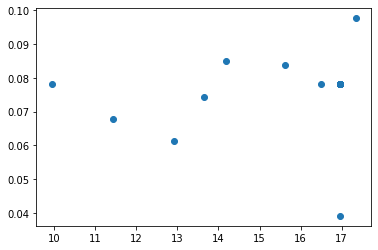

In [33]:
plt.scatter(solarRCP62020['Capacity factor'], solarRCP62020['GWP'])

In [34]:
endTime = time.time() # end time
elapsedTime = endTime - startTime # calculate elapsed time
print(f'Elapsed time: {elapsedTime/3600:.2f} hours') 

Elapsed time: 0.00 hours
